# Background

In [ ]:
%pip install ipywidgets ipympl

## Definitions

An *ordinary differential equation* (ODE) contains one or more derivatives of
an unknown function of one variable.

\begin{align}
&y' = \cos x \\
&y'' + 9y = 0 \\
&x^2 y''' y' + 2e^x y^4 = (x^2 + 2)y^2
\end{align}

The *order* of an ODE is its highest derivative. The examples above are
first order, second order, and third order ODEs, respectively, because their
highest-order derivatives are $y'$, $y''$, and $y'''$. This chapter is focused
only on first-order ODEs, but we will learn about
[second-order ODEs](../second-order-odes/index.md) later.

First-order ODEs can be written most generally in *implicit* form:

\begin{equation}
F(x, y, y') = 0
\end{equation}

where *F* is an arbitrary function of the independent variable *x*, the
dependent variable (unknown function) *y*, and its derivative *y*'.
First-order ODEs can sometimes also be written in *explicit* form:

\begin{equation}
y' = f(x, y)
\end{equation}

where *f* is an arbitrary function of only *y* and *y*'. Not all first-order
ODEs can be written in explicit form: you have to be able to isolate *y*' from
*x* and *y*.

## Direction fields and initial value problems

The *general solution* to a first-order ODE will contain a constant *c*, so
first-order ODEs have a family of solutions depending on the constant *c*.

Graphically, an explicit first-order ODE can be represented by a *direction
field* (or slope field) showing the tangent to a particular solution in this
family at a point (*x*, *y*) because *y*' represents the local rate of change.
Starting from a point $(x_0, y_0)$ and tracing a curve through the direction
field gives a *particular solution*, which corresponds to a certain value of
*c*. Repeating this process for different starting points generates the
family of solutions.

The point you start from is called an *initial condition*, and a
first-order ODE paired with an initial condition is called an
*initial value problem*. Initial value problems are very important for chemical
engineering because they show how a dependent quantity evolves from a known
starting point in time or space.

As an example, consider the first-order ODE

\begin{equation}
y' = xy
\end{equation}

(-2.0, 2.0)

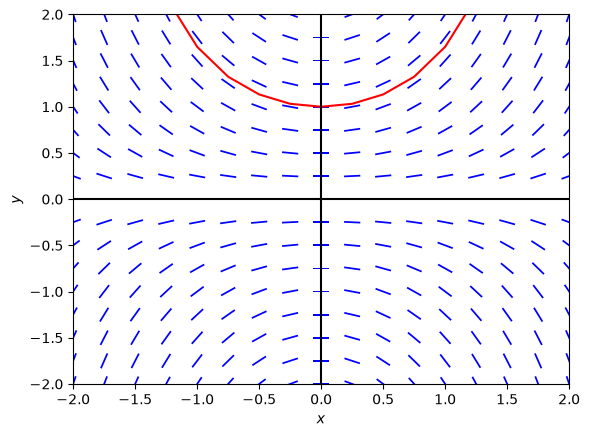

In [ ]:
%matplotlib widget
import ipywidgets
import numpy
import matplotlib.pyplot

x = numpy.linspace(-2, 2, 17)
y = numpy.linspace(-2, 2, 17)
X, Y = numpy.meshgrid(x, y)

dx = numpy.ones_like(X)
dy = X * Y
norm = numpy.sqrt(dx**2 + dy**2)
U = dx / norm
V = dy / norm

def analytical_solution(x0, y0):
    return (y0 / numpy.exp(x0**2 / 2)) * numpy.exp(x**2 / 2)

fig, ax = matplotlib.pyplot.subplots()
ax.quiver(X, Y, U, V, pivot="mid", angles="xy", headwidth=0, headlength=0, headaxislength=0, color="blue")
line = ax.plot(x, analytical_solution(0, 1), color="red")
ax.axhline(0, x[0], x[-1], color="black")
ax.axvline(0, y[0], y[-1], color="black")
ax.set_xlabel("$x$")
ax.set_xlim((x[0], x[-1]))
ax.set_ylabel("$y$")
ax.set_ylim((y[0], y[-1]))

@ipywidgets.interact(x0=(-2, 2, 0.5), y0=(-1, 1, 0.1))
def update(x0=0.0, y0=1.0):
    ax.plot(x, analytical_solution(x0, y0), color="red")

Verify that

\begin{equation}
y = c e^{x^2 / 2}
\end{equation}

is a general solution.

Now, let's verify the proposed solution. The first derivative of *y* is

\begin{equation}
y' = c x e^{x^2/2}
\end{equation}

Substituting *y* and $y'$ in the differential equation

\begin{align}
y' &= x y \\
c x e^{x^2 / 2} &= x (c e^{x^2 / 2})
\end{align}

shows this is indeed a solution.

For the first-order ODE above, find the solution when $y(0) = 1$.

---

Substitute $x = 0$ and $y = 1$ into the general solution $y = c e^{-x^2/2}$
to determine $c$:

\begin{equation}
1 = y(0) = c e^0 = c
\end{equation}

This gives the solution

\begin{equation}
y = e^{x^2/2}
\end{equation}